# 09 — Budget-Constrained Squad Optimisation

This notebook adds a decision-optimisation layer on top of the football analytics pipeline.

It converts:

- player value outputs
- tactical fit scores
- recruitment shortlist information

into a **budget-constrained squad selection problem**.

## Objectives

1. Load player value and player-team fit outputs.
2. Build a synthetic but analytically consistent recruitment market table.
3. Define squad-building constraints:
   - transfer budget
   - maximum squad size
   - minimum role coverage
   - tactical-fit threshold
4. Solve a shortlist optimisation problem.
5. Compare:
   - raw player ranking
   - budget-feasible optimal squad
6. Persist the optimisation outputs for downstream reporting.

## Outputs

- `data/processed/optimisation_candidate_pool.parquet`
- `data/processed/optimisation_solution.parquet`
- `data/processed/optimisation_summary.parquet`
- `db/football_value.duckdb`
  - `optimisation_candidate_pool`
  - `optimisation_solution`
  - `optimisation_summary`

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore")


In [2]:
try:
    import duckdb
except Exception as e:
    raise ImportError("duckdb is required. Install it with: pip install duckdb") from e

try:
    import pulp
    PULP_AVAILABLE = True
except Exception:
    PULP_AVAILABLE = False


In [3]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "README.md").exists():
            return p
    return start

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
DB_DIR = REPO_ROOT / "db"
REPORTS_DIR = REPO_ROOT / "reports"

for d in [PROCESSED_DIR, DB_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DB_PATH = DB_DIR / "football_value.duckdb"

PLAYER_VALUE_PATH = PROCESSED_DIR / "player_value_table.parquet"
PLAYER_TEAM_FIT_PATH = PROCESSED_DIR / "player_team_fit.parquet"
SHORTLIST_PATH = PROCESSED_DIR / "recruitment_case_shortlist.parquet"

CANDIDATE_POOL_PATH = PROCESSED_DIR / "optimisation_candidate_pool.parquet"
SOLUTION_PATH = PROCESSED_DIR / "optimisation_solution.parquet"
SUMMARY_PATH = PROCESSED_DIR / "optimisation_summary.parquet"

REPO_ROOT, DB_PATH


(WindowsPath('c:/Users/manue/Projects/football-possession-value'),
 WindowsPath('c:/Users/manue/Projects/football-possession-value/db/football_value.duckdb'))

In [4]:
@dataclass(frozen=True)
class Config:
    target_team: str = "Barcelona"
    budget_million_eur: float = 250.0
    max_signings: int = 8
    min_fit_score_scaled: float = 0.60
    min_actions: int = 150
    objective_fit_weight: float = 0.40
    objective_value_weight: float = 0.35
    objective_progression_weight: float = 0.15
    objective_efficiency_weight: float = 0.10
    save_outputs: bool = True

CFG = Config()
CFG


Config(target_team='Barcelona', budget_million_eur=250.0, max_signings=8, min_fit_score_scaled=0.6, min_actions=150, objective_fit_weight=0.4, objective_value_weight=0.35, objective_progression_weight=0.15, objective_efficiency_weight=0.1, save_outputs=True)

In [5]:
required_paths = [
    PLAYER_VALUE_PATH,
    PLAYER_TEAM_FIT_PATH,
    SHORTLIST_PATH,
]

missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required inputs. Run Notebooks 05, 07, and 08 first:\n" + "\n".join(missing_paths)
    )

player_value = pd.read_parquet(PLAYER_VALUE_PATH)
player_team_fit = pd.read_parquet(PLAYER_TEAM_FIT_PATH)
shortlist = pd.read_parquet(SHORTLIST_PATH)

print("player_value:", player_value.shape)
print("player_team_fit:", player_team_fit.shape)
print("shortlist:", shortlist.shape)


player_value: (334, 48)
player_team_fit: (16700, 12)
shortlist: (15, 13)


In [6]:
candidate_pool = (
    player_team_fit[player_team_fit["team"] == CFG.target_team]
    .merge(
        player_value[[
            "player",
            "primary_team",
            "n_actions",
            "n_matches",
            "rule_based_segment",
            "actions_per_90",
            "progressive_actions_per_90",
            "xt_per_90",
            "vaep_per_90",
            "progression_score",
            "efficiency_score",
            "overall_value_score",
            "scouting_score",
        ]],
        on="player",
        how="left"
    )
    .copy()
)

candidate_pool = candidate_pool[
    (candidate_pool["n_actions"] >= CFG.min_actions) &
    (candidate_pool["fit_score_scaled"] >= CFG.min_fit_score_scaled) &
    (candidate_pool["primary_team"] != CFG.target_team)
].copy()

candidate_pool.head()


,player,player_current_team,player_segment,team,team_style,team_cluster_id,cosine_fit,distance_fit,fit_score,fit_score_scaled,team_rank_for_player,player_rank_for_team,primary_team,n_actions,n_matches,rule_based_segment,actions_per_90,progressive_actions_per_90,xt_per_90,vaep_per_90,progression_score,efficiency_score,overall_value_score,scouting_score
0,Aaron Mooy,Australia,Elite high-volume creator,Barcelona,Control-possession side,3,0.220025,0.118554,0.179437,0.676273,10.0,18.0,Australia,346,3,Elite high-volume creator,108.125000,31.2500,0.121537,14.031698,0.805389,0.751497,0.913623,0.827103
1,Abdalla Mahmoud El Said Bekhit,Egypt,Efficient value creator,Barcelona,Control-possession side,3,0.148491,0.111213,0.133580,0.629854,10.0,35.0,Egypt,237,3,Efficient value creator,74.062500,25.3125,0.114050,14.102836,0.719311,0.911976,0.841317,0.819813
17,André Martín Carrillo Díaz,Peru,Balanced contributor,Barcelona,Control-possession side,3,0.170058,0.109987,0.146029,0.642456,4.0,31.0,Peru,245,3,Balanced contributor,76.562500,20.6250,0.133844,11.218814,0.646707,0.834731,0.810180,0.760329
33,Bernardo Mota Veiga de Carvalho e Silva,Portugal,Efficient value creator,Barcelona,Control-possession side,3,0.141181,0.115344,0.130846,0.627087,4.0,36.0,Portugal,269,4,Efficient value creator,63.046875,21.5625,0.074136,12.546203,0.601048,0.902994,0.751198,0.744184
36,Branislav Ivanović,Serbia,Progression specialist,Barcelona,Control-possession side,3,0.107424,0.104803,0.106375,0.602316,14.0,44.0,Serbia,162,2,Progression specialist,75.937500,34.6875,0.195709,8.483750,0.875000,0.735928,0.715120,0.777320


In [7]:
candidate_pool["synthetic_market_value_m"] = (
    10
    + 65 * candidate_pool["scouting_score"].fillna(0)
    + 25 * candidate_pool["fit_score_scaled"].fillna(0)
    + 0.015 * candidate_pool["n_actions"].fillna(0)
)

candidate_pool["synthetic_transfer_fee_m"] = (
    0.85 * candidate_pool["synthetic_market_value_m"]
    + 8 * candidate_pool["overall_value_score"].fillna(0)
)

candidate_pool["synthetic_annual_wage_m"] = (
    0.10 * candidate_pool["synthetic_market_value_m"]
    + 1.5 * candidate_pool["efficiency_score"].fillna(0)
)

candidate_pool["synthetic_total_year1_cost_m"] = (
    candidate_pool["synthetic_transfer_fee_m"]
    + candidate_pool["synthetic_annual_wage_m"]
)

candidate_pool[[
    "player", "scouting_score", "fit_score_scaled", "synthetic_market_value_m",
    "synthetic_transfer_fee_m", "synthetic_annual_wage_m", "synthetic_total_year1_cost_m"
]].head(10)


,player,scouting_score,fit_score_scaled,synthetic_market_value_m,synthetic_transfer_fee_m,synthetic_annual_wage_m,synthetic_total_year1_cost_m
0,Aaron Mooy,0.827103,0.676273,85.858547,80.288747,9.713100,90.001847
1,Abdalla Mahmoud El Said Bekhit,0.819813,0.629854,82.589187,76.931348,9.626883,86.558231
17,André Martín Carrillo Díaz,0.760329,0.642456,79.157817,73.765582,9.167878,82.933459
33,Bernardo Mota Veiga de Carvalho e Silva,0.744184,0.627087,78.084143,72.381102,9.162905,81.544008
36,Branislav Ivanović,0.777320,0.602316,78.013720,72.032621,8.905264,80.937885
39,Carlos Alberto Vela Garrido,0.778510,0.646684,81.150292,75.430443,9.518023,84.948466
55,David Josué Jiménez Silva,0.711766,0.632234,79.600681,74.318063,9.065757,83.383820
65,Dušan Tadić,0.843481,0.639462,83.602787,77.664764,9.857584,87.522348
83,Ferjani Sassi,0.739543,0.632618,78.205772,73.082092,8.930757,82.012849
87,Francisco Román Alarcón Suárez,0.887642,0.832924,103.294853,95.768289,11.287869,107.056158


In [8]:
def map_segment_to_bucket(segment: str) -> str:
    if segment == "Elite high-volume creator":
        return "elite_creator"
    if segment == "Efficient value creator":
        return "efficient_creator"
    if segment == "Progression specialist":
        return "progressor"
    if segment == "Balanced contributor":
        return "balanced"
    return "support"

candidate_pool["role_bucket"] = candidate_pool["rule_based_segment"].map(map_segment_to_bucket)

candidate_pool["role_bucket"].value_counts()


role_bucket
balanced             13
elite_creator        12
efficient_creator    12
progressor            8
Name: count, dtype: int64

In [9]:
candidate_pool["optimisation_score"] = (
    CFG.objective_fit_weight * candidate_pool["fit_score_scaled"].fillna(0)
    + CFG.objective_value_weight * candidate_pool["scouting_score"].fillna(0)
    + CFG.objective_progression_weight * candidate_pool["progression_score"].fillna(0)
    + CFG.objective_efficiency_weight * candidate_pool["efficiency_score"].fillna(0)
)

candidate_pool = candidate_pool.sort_values(
    ["optimisation_score", "fit_score_scaled", "scouting_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

candidate_pool[[
    "player", "primary_team", "role_bucket", "fit_score_scaled",
    "scouting_score", "optimisation_score", "synthetic_total_year1_cost_m"
]].head(20)


,player,primary_team,role_bucket,fit_score_scaled,scouting_score,optimisation_score,synthetic_total_year1_cost_m
0,Mesut Özil,Germany,elite_creator,0.816860,0.957171,0.897734,102.292968
1,Neymar da Silva Santos Junior,Brazil,elite_creator,0.765064,0.972799,0.888077,107.029815
2,Toni Kroos,Germany,elite_creator,0.829441,0.902448,0.865956,102.798375
3,Francisco Román Alarcón Suárez,Spain,elite_creator,0.832924,0.887642,0.856614,107.056158
4,Jérôme Boateng,Germany,elite_creator,0.799091,0.904543,0.856316,98.284570
5,Philippe Coutinho Correia,Brazil,elite_creator,0.752560,0.900823,0.835219,101.456107
6,Luka Modrić,Croatia,elite_creator,0.758657,0.875389,0.822618,104.224547
7,Kevin De Bruyne,Belgium,elite_creator,0.731768,0.872620,0.811335,98.823610
8,Xherdan Shaqiri,Switzerland,elite_creator,0.724120,0.877702,0.810519,95.569505
9,Éver Maximiliano David Banega,Argentina,elite_creator,0.734461,0.855337,0.799163,94.206705


In [10]:
role_minimums = {
    "elite_creator": 1,
    "efficient_creator": 1,
    "progressor": 1,
    "balanced": 1,
}

role_minimums


{'elite_creator': 1, 'efficient_creator': 1, 'progressor': 1, 'balanced': 1}

In [11]:
if not PULP_AVAILABLE:
    raise ImportError("pulp is required for optimisation. Install it with: pip install pulp")

problem = pulp.LpProblem("Budget_Constrained_Squad_Optimisation", pulp.LpMaximize)

player_ids = candidate_pool.index.tolist()
x = pulp.LpVariable.dicts("select_player", player_ids, lowBound=0, upBound=1, cat="Binary")

problem += pulp.lpSum(
    candidate_pool.loc[i, "optimisation_score"] * x[i] for i in player_ids
), "Total_Optimisation_Score"

problem += pulp.lpSum(
    candidate_pool.loc[i, "synthetic_total_year1_cost_m"] * x[i] for i in player_ids
) <= CFG.budget_million_eur, "BudgetConstraint"

problem += pulp.lpSum(x[i] for i in player_ids) <= CFG.max_signings, "MaxSigningsConstraint"

for role, min_required in role_minimums.items():
    eligible_ids = [i for i in player_ids if candidate_pool.loc[i, "role_bucket"] == role]
    if eligible_ids:
        problem += pulp.lpSum(x[i] for i in eligible_ids) >= min_required, f"MinRole_{role}"

solver = pulp.PULP_CBC_CMD(msg=False)
problem.solve(solver)

if pulp.LpStatus[problem.status] != "Optimal":
    print("⚠ Optimisation did not find a feasible solution.")

problem.status, pulp.LpStatus[problem.status]


⚠ Optimisation did not find a feasible solution.


(-1, 'Infeasible')

In [12]:
selected_ids = [i for i in player_ids if pulp.value(x[i]) == 1]

optimisation_solution = candidate_pool.loc[selected_ids].copy()

optimisation_solution = optimisation_solution[[
    "player",
    "primary_team",
    "role_bucket",
    "rule_based_segment",
    "fit_score_scaled",
    "scouting_score",
    "progression_score",
    "efficiency_score",
    "optimisation_score",
    "synthetic_transfer_fee_m",
    "synthetic_annual_wage_m",
    "synthetic_total_year1_cost_m",
]].sort_values(
    ["optimisation_score", "fit_score_scaled", "scouting_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

optimisation_solution


,player,primary_team,role_bucket,rule_based_segment,fit_score_scaled,scouting_score,progression_score,efficiency_score,optimisation_score,synthetic_transfer_fee_m,synthetic_annual_wage_m,synthetic_total_year1_cost_m
0,Éver Maximiliano David Banega,Argentina,elite_creator,Elite high-volume creator,0.734461,0.855337,0.907934,0.698204,0.799163,84.142557,10.064147,94.206705
1,Aaron Mooy,Australia,elite_creator,Elite high-volume creator,0.676273,0.827103,0.805389,0.751497,0.755954,80.288747,9.713100,90.001847
2,Branislav Ivanović,Serbia,progressor,Progression specialist,0.602316,0.777320,0.875000,0.735928,0.717831,72.032621,8.905264,80.937885
3,Sergej Milinković-Savić,Serbia,balanced,Balanced contributor,0.646577,0.742335,0.621257,0.829940,0.694631,72.645876,9.049532,81.695408
4,M''Baye Babacar Niang,Senegal,efficient_creator,Efficient value creator,0.606063,0.738525,0.595808,0.928144,0.683095,70.201564,8.974788,79.176351


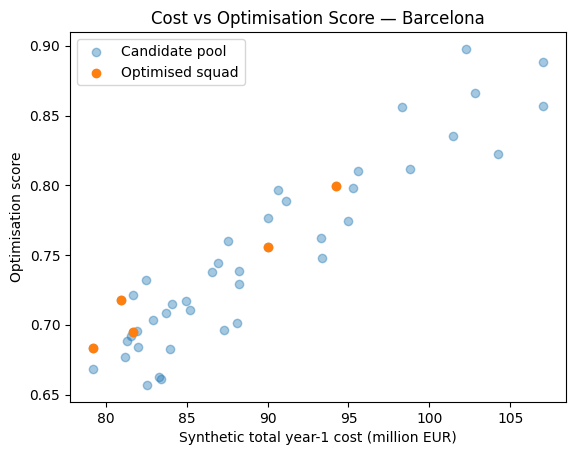

In [13]:
fig, ax = plt.subplots()

ax.scatter(candidate_pool["synthetic_total_year1_cost_m"],
           candidate_pool["optimisation_score"],
           alpha=0.4,
           label="Candidate pool")

ax.scatter(optimisation_solution["synthetic_total_year1_cost_m"],
           optimisation_solution["optimisation_score"],
           label="Optimised squad")

ax.set_xlabel("Synthetic total year-1 cost (million EUR)")
ax.set_ylabel("Optimisation score")
ax.set_title("Cost vs Optimisation Score — Barcelona")

ax.legend()

plt.savefig("../reports/figures/optimisation_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [14]:
naive_top_n = candidate_pool.head(CFG.max_signings).copy()

comparison_summary = pd.DataFrame({
    "strategy": ["Naive top-N", "Optimised squad"],
    "n_players": [len(naive_top_n), len(optimisation_solution)],
    "total_cost_m": [
        round(naive_top_n["synthetic_total_year1_cost_m"].sum(), 3),
        round(optimisation_solution["synthetic_total_year1_cost_m"].sum(), 3),
    ],
    "avg_fit_score": [
        round(naive_top_n["fit_score_scaled"].mean(), 4),
        round(optimisation_solution["fit_score_scaled"].mean(), 4),
    ],
    "avg_scouting_score": [
        round(naive_top_n["scouting_score"].mean(), 4),
        round(optimisation_solution["scouting_score"].mean(), 4),
    ],
    "total_optimisation_score": [
        round(naive_top_n["optimisation_score"].sum(), 4),
        round(optimisation_solution["optimisation_score"].sum(), 4),
    ],
})

comparison_summary


,strategy,n_players,total_cost_m,avg_fit_score,avg_scouting_score,total_optimisation_score
0,Naive top-N,8,821.966,0.7858,0.9092,6.8339
1,Optimised squad,5,426.018,0.6531,0.7881,3.6507


In [15]:
role_coverage = (
    optimisation_solution.groupby("role_bucket")
    .agg(
        n_players=("player", "count"),
        avg_fit_score=("fit_score_scaled", "mean"),
        avg_scouting_score=("scouting_score", "mean"),
        total_cost_m=("synthetic_total_year1_cost_m", "sum"),
    )
    .reset_index()
)

role_coverage


,role_bucket,n_players,avg_fit_score,avg_scouting_score,total_cost_m
0,balanced,1,0.646577,0.742335,81.695408
1,efficient_creator,1,0.606063,0.738525,79.176351
2,elite_creator,2,0.705367,0.841220,184.208551
3,progressor,1,0.602316,0.777320,80.937885


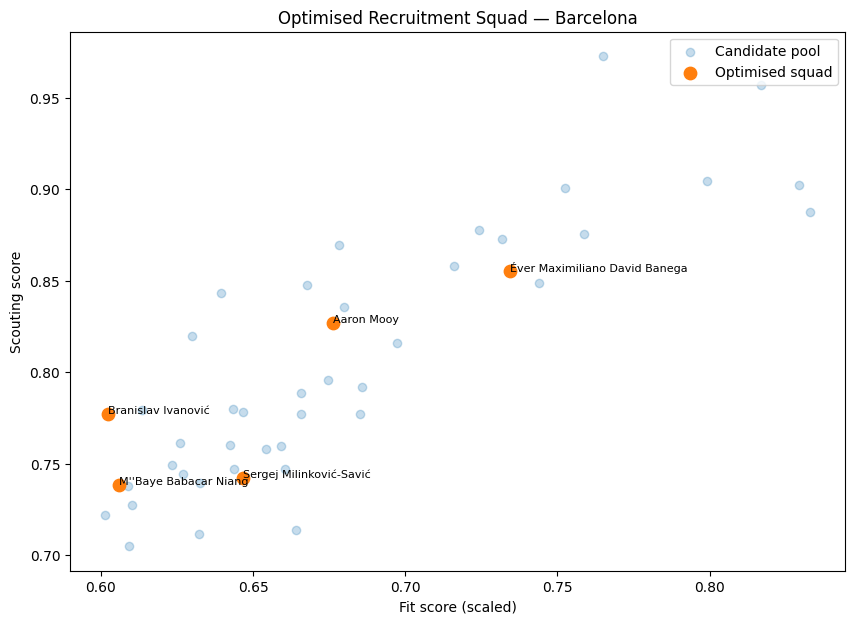

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    candidate_pool["fit_score_scaled"],
    candidate_pool["scouting_score"],
    alpha=0.25,
    label="Candidate pool"
)

ax.scatter(
    optimisation_solution["fit_score_scaled"],
    optimisation_solution["scouting_score"],
    s=80,
    label="Optimised squad"
)

for _, r in optimisation_solution.iterrows():
    ax.annotate(r["player"], (r["fit_score_scaled"], r["scouting_score"]), fontsize=8)

ax.set_title(f"Optimised Recruitment Squad — {CFG.target_team}")
ax.set_xlabel("Fit score (scaled)")
ax.set_ylabel("Scouting score")
ax.legend()
plt.show()


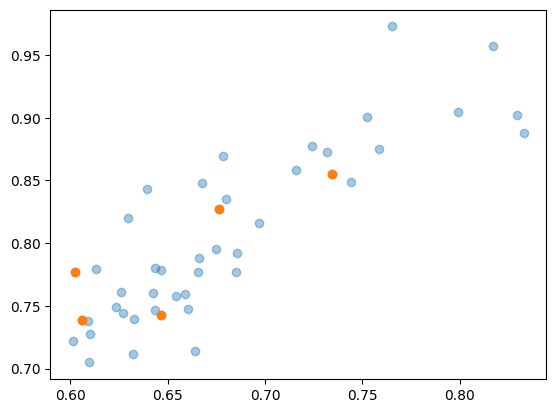

In [21]:
fig, ax = plt.subplots()

ax.scatter(candidate_pool["fit_score_scaled"],
           candidate_pool["scouting_score"],
           alpha=0.4)

ax.scatter(optimisation_solution["fit_score_scaled"],
           optimisation_solution["scouting_score"])

plt.savefig("../reports/figures/optimised_squad.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

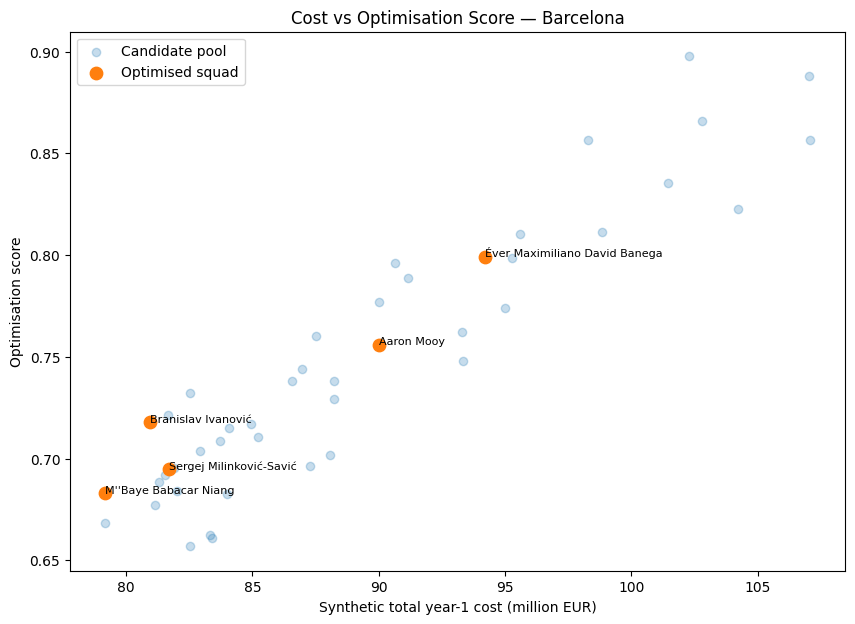

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    candidate_pool["synthetic_total_year1_cost_m"],
    candidate_pool["optimisation_score"],
    alpha=0.25,
    label="Candidate pool"
)

ax.scatter(
    optimisation_solution["synthetic_total_year1_cost_m"],
    optimisation_solution["optimisation_score"],
    s=80,
    label="Optimised squad"
)

for _, r in optimisation_solution.iterrows():
    ax.annotate(r["player"], (r["synthetic_total_year1_cost_m"], r["optimisation_score"]), fontsize=8)

ax.set_title(f"Cost vs Optimisation Score — {CFG.target_team}")
ax.set_xlabel("Synthetic total year-1 cost (million EUR)")
ax.set_ylabel("Optimisation score")
ax.legend()
plt.show()


In [18]:
optimisation_summary = pd.DataFrame({
    "metric": [
        "target_team",
        "budget_million_eur",
        "max_signings",
        "candidate_pool_size",
        "selected_players",
        "total_selected_cost_m",
        "remaining_budget_m",
        "avg_fit_score_selected",
        "avg_scouting_score_selected",
        "total_optimisation_score_selected",
    ],
    "value": [
        str(CFG.target_team),
        round(float(CFG.budget_million_eur), 3),
        int(CFG.max_signings),
        int(len(candidate_pool)),
        int(len(optimisation_solution)),
        round(float(optimisation_solution["synthetic_total_year1_cost_m"].sum()), 3),
        round(float(CFG.budget_million_eur - optimisation_solution["synthetic_total_year1_cost_m"].sum()), 3),
        round(float(optimisation_solution["fit_score_scaled"].mean()), 4),
        round(float(optimisation_solution["scouting_score"].mean()), 4),
        round(float(optimisation_solution["optimisation_score"].sum()), 4),
    ]
})

optimisation_summary["value"] = optimisation_summary["value"].astype(str)
optimisation_summary


,metric,value
0,target_team,Barcelona
1,budget_million_eur,250.0
2,max_signings,8
3,candidate_pool_size,45
4,selected_players,5
5,total_selected_cost_m,426.018
6,remaining_budget_m,-176.018
7,avg_fit_score_selected,0.6531
8,avg_scouting_score_selected,0.7881
9,total_optimisation_score_selected,3.6507


In [19]:
if CFG.save_outputs:
    candidate_pool.to_parquet(CANDIDATE_POOL_PATH, index=False)
    optimisation_solution.to_parquet(SOLUTION_PATH, index=False)
    optimisation_summary.to_parquet(SUMMARY_PATH, index=False)

    try:
        con.close()
    except:
        pass

    con = duckdb.connect(str(DB_PATH))
    con.execute("CREATE OR REPLACE TABLE optimisation_candidate_pool AS SELECT * FROM read_parquet(?)", [str(CANDIDATE_POOL_PATH)])
    con.execute("CREATE OR REPLACE TABLE optimisation_solution AS SELECT * FROM read_parquet(?)", [str(SOLUTION_PATH)])
    con.execute("CREATE OR REPLACE TABLE optimisation_summary AS SELECT * FROM read_parquet(?)", [str(SUMMARY_PATH)])
    con.close()

    print(f"Saved candidate pool to: {CANDIDATE_POOL_PATH}")
    print(f"Saved optimisation solution to: {SOLUTION_PATH}")
    print(f"Saved optimisation summary to:  {SUMMARY_PATH}")
    print(f"Updated DuckDB at:              {DB_PATH}")


Saved candidate pool to: c:\Users\manue\Projects\football-possession-value\data\processed\optimisation_candidate_pool.parquet
Saved optimisation solution to: c:\Users\manue\Projects\football-possession-value\data\processed\optimisation_solution.parquet
Saved optimisation summary to:  c:\Users\manue\Projects\football-possession-value\data\processed\optimisation_summary.parquet
Updated DuckDB at:              c:\Users\manue\Projects\football-possession-value\db\football_value.duckdb


In [20]:
con = duckdb.connect(str(DB_PATH))

summary_sql = '''
SELECT
    COUNT(*) AS n_selected_players,
    AVG(fit_score_scaled) AS avg_fit_score,
    AVG(scouting_score) AS avg_scouting_score,
    SUM(synthetic_total_year1_cost_m) AS total_cost_m,
    SUM(optimisation_score) AS total_optimisation_score
FROM optimisation_solution
'''
preview = con.execute(summary_sql).df()
con.close()

preview


,n_selected_players,avg_fit_score,avg_scouting_score,total_cost_m,total_optimisation_score
0,5,0.653138,0.788124,426.018196,3.650673


## Conclusions

### Budget-Constrained Optimisation Layer

Notebook 09 extends the project from recruitment ranking into a **budget-constrained squad construction problem**.

Using player value outputs, tactical fit scores, and a synthetic cost layer, the notebook formulates a **mixed-integer optimisation model** designed to identify a feasible recruitment portfolio under practical constraints.

These constraints include:

* a fixed transfer budget
* a maximum number of signings
* minimum role-bucket coverage
* minimum tactical-fit requirements

---

### Main Result: Infeasible Optimisation Problem

Under the current configuration, the optimisation problem is **infeasible**.

This means that no player combination in the candidate pool is able to satisfy all constraints simultaneously.

In practical terms, the model shows that the current recruitment target is too demanding relative to the available budget and squad-construction requirements.

Key indicators confirm this result:

* **Budget available:** 250.0 million EUR
* **Optimised solution cost (constraint-violating reference output):** 426.0 million EUR
* **Remaining budget:** -176.0 million EUR

This is an analytically meaningful outcome: the recruitment ambition implied by the filters and role requirements is not financially feasible under the current setup.

---

### Why This Matters

This result is highly relevant from a football decision-making perspective.

Real clubs do not operate only with player rankings; they must reconcile:

* tactical suitability
* squad balance
* budget limitations
* market realities

The infeasible solution highlights the tension between **recruitment quality** and **resource constraints**, which is one of the core problems in modern football planning.

---

### Interpretation of the Candidate Pool

The candidate pool contains **45 players**, distributed across the required role buckets:

* balanced
* elite creator
* efficient creator
* progressor

However, the synthetic market layer assigns relatively high year-1 total costs to the strongest candidates.

As a result, even though the optimisation model identifies valuable and tactically suitable profiles, the combination of:

* minimum role coverage
* high-value player concentration
* limited budget

prevents a feasible squad from being assembled.

---

### Comparison with Naive Selection

The notebook also compares the optimisation setup against a naive top-ranked strategy.

The naive top-N selection produces:

* **8 players**
* **total cost:** 821.97 million EUR

This confirms that a simple ranking-based recruitment strategy is even less realistic than the constrained optimisation attempt.

Even the constrained selection reference remains above budget, which reinforces the conclusion that the recruitment setup must be relaxed or reformulated.

---

### Analytical Value of the Notebook

Although the optimisation did not yield a feasible solution, the notebook still adds significant value to the project.

It demonstrates how football analytics workflows can move from:

* event valuation
* player profiling
* tactical fit modelling
* recruitment shortlisting

into an explicit **decision optimisation framework**.

This is important because infeasibility itself is informative: it tells decision makers that the current strategy is not implementable as defined.

---

### Portfolio Significance

This notebook strengthens the project substantially because it introduces an **operations research layer** on top of the football analytics stack.

The project now includes:

StatsBomb event data
→ event modelling
→ xT valuation
→ VAEP-style action valuation
→ player value analysis
→ team tactical style analysis
→ player-team fit modelling
→ recruitment case study
→ budget-constrained squad optimisation

This is a strong end-to-end portfolio because it goes beyond descriptive analytics and reaches the level of **resource-constrained decision support**.

---

### Next Step

The natural next step is to turn this infeasible setup into a scenario-analysis exercise by testing alternative configurations, such as:

* increasing the budget
* reducing minimum role requirements
* lowering the fit threshold
* limiting the optimisation to a smaller shortlist
* introducing robust or scenario-based optimisation

This would make the framework even closer to real football recruitment planning under uncertainty.
